In [3]:
import pandas as pd
import pyodbc

conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=salesdb;"
    "Trusted_Connection=yes;"
)

df = pd.read_sql("SELECT * FROM SALES", conn)

print(df.head())

C:\Users\iremm\AppData\Local\Temp\ipykernel_1112\56443048.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM SALES", conn)


  Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0      1  MX-2014-143658  2014-10-02  2014-10-06  Standard Class    SC-20575   
1     10  MX-2013-134096  2013-09-27  2013-10-01  Standard Class    DP-13000   
2    100  US-2013-125892  2013-08-08  2013-08-10     First Class    NW-18400   
3   1000  MX-2013-126361  2013-12-17  2013-12-19    Second Class    AH-10690   
4  10000  US-2012-142734  2012-10-15  2012-10-20  Standard Class    KW-16570   

    Customer_Name    Segment           City             State  ...  \
0    Sonia Cooley   Consumer    Mexico City  Distrito Federal  ...   
1   Darren Powers   Consumer      São Paulo         São Paulo  ...   
2  Natalie Webber   Consumer  Santo Domingo     Santo Domingo  ...   
3   Anna Häberlin  Corporate        Granada           Granada  ...   
4  Kelly Williams   Consumer        Indaial    Santa Catarina  ...   

          Category Sub_Category                               Product_Name  \
0  Office Supplies  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row_ID          51290 non-null  object 
 1   Order_ID        51290 non-null  object 
 2   Order_Date      51290 non-null  object 
 3   Ship_Date       51290 non-null  object 
 4   Ship_Mode       51290 non-null  object 
 5   Customer_ID     51290 non-null  object 
 6   Customer_Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Market          51290 non-null  object 
 12  Region          51290 non-null  object 
 13  Product_ID      51290 non-null  object 
 14  Category        51290 non-null  object 
 15  Sub_Category    51290 non-null  object 
 16  Product_Name    51290 non-null  object 
 17  Sales           51290 non-null 

In [5]:
df["Ship_Mode"].unique() # Kaç çeşit teslimat yöntemi var?

array(['Standard Class', 'First Class', 'Second Class', 'Same Day'],
      dtype=object)

In [6]:
df["Segment"].unique() # Kaç çeşit müşteri var?

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [7]:
df["Country"].unique()

array(['Mexico', 'Brazil', 'Dominican Republic', 'Nicaragua', 'Paraguay',
       'Uruguay', 'Panama', 'Guatemala', 'Cuba', 'El Salvador',
       'United Kingdom', 'France', 'Germany', 'Italy', 'Spain', 'Haiti',
       'Netherlands', 'Sweden', 'Belgium', 'Austria', 'Peru', 'Honduras',
       'Ireland', 'Portugal', 'Chile', 'Colombia', 'Argentina', 'Finland',
       'Denmark', 'Norway', 'Switzerland', 'Jamaica', 'Bolivia',
       'Venezuela', 'Martinique', 'Barbados', 'Ecuador', 'China',
       'Philippines', 'India', 'Japan', 'Australia', 'Indonesia',
       'Vietnam', 'Malaysia', 'Thailand', 'Cambodia', 'Pakistan',
       'Myanmar (Burma)', 'South Korea', 'Nepal', 'Afghanistan',
       'Bangladesh', 'Hong Kong', 'Singapore', 'Sri Lanka',
       'Papua New Guinea', 'Mongolia', 'Trinidad and Tobago', 'Taiwan',
       'Guadeloupe', 'New Zealand', 'United States', 'Cameroon', 'Egypt',
       'Poland', 'Russia', 'Ukraine', 'Morocco', 'Israel', 'Saudi Arabia',
       'Iran', 'Ghana', 'South 

In [8]:
df["Region"].unique()

array(['North', 'South', 'Caribbean', 'Central', 'North Asia',
       'Southeast Asia', 'Central Asia', 'Oceania', 'West', 'East',
       'Africa', 'EMEA', 'Canada'], dtype=object)

In [9]:
df["Category"].unique()

array(['Office Supplies', 'Technology', 'Furniture'], dtype=object)

In [10]:
df["Sub_Category"].unique()

array(['Labels', 'Accessories', 'Paper', 'Phones', 'Envelopes',
       'Machines', 'Supplies', 'Binders', 'Fasteners', 'Chairs', 'Art',
       'Furnishings', 'Copiers', 'Storage', 'Appliances', 'Tables',
       'Bookcases'], dtype=object)

In [11]:
df["Order_Priority"].unique()

array(['Medium', 'Critical', 'High', 'Low'], dtype=object)

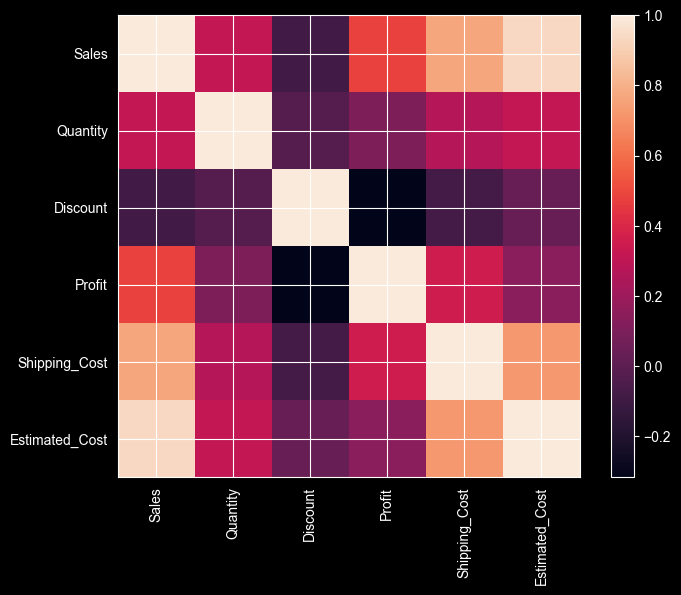

In [12]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [13]:
df.groupby("Category")[["Sales","Profit","Estimated_Cost"]].sum()

,Sales,Profit,Estimated_Cost
Category,,,
Furniture,4110874.242,285204.7238,3.825670e+06
Office Supplies,3787070.355,518473.8343,3.268597e+06
Technology,4744557.624,663778.7341,4.080779e+06


In [14]:
(df.groupby("Category")["Profit"].sum() /
 df.groupby("Category")["Sales"].sum()) * 100

Category
Furniture           6.937812
Office Supplies    13.690631
Technology         13.990319
dtype: float64

In [15]:
df.groupby("Country")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)

,Sales,Profit
Country,,
United States,2297200.867,286397.0217
Australia,925235.853,103907.4330
France,858931.150,109029.0030
China,700562.025,150683.0850
Germany,628840.034,107322.8205
...,...,...
Tajikistan,242.784,-262.8660
Macedonia,209.640,43.3800
Eritrea,187.740,76.2000


In [16]:
df.groupby("Ship_Mode")[["Sales","Profit"]].mean()

,Sales,Profit
Ship_Mode,,
First Class,243.967512,27.728804
Same Day,247.020363,28.201802
Second Class,248.876879,28.381368
Standard Class,246.260026,28.938945


In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"])
#Date Time dönüştürüyoruz.

In [18]:
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day_name()

df["Delivery_Days"] = (
    df["Ship_Date"] - df["Order_Date"]
).dt.days

In [19]:
df.describe()

,Order_Date,Ship_Date,Sales,Quantity,Discount,Profit,Shipping_Cost,Estimated_Cost,Order_Year,Order_Month,Delivery_Days
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.490587,3.476545,0.142908,28.610982,26.375915,217.879605,2012.777208,7.522636,3.969370
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.000000,0.554400,2011.000000,1.000000,0.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,30.758750,2.000000,0.000000,0.000000,2.610000,26.880000,2012.000000,5.000000,3.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.053000,3.000000,0.000000,9.240000,7.790000,73.635000,2013.000000,8.000000,4.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.053500,5.000000,0.200000,36.810000,24.450000,222.964850,2014.000000,10.000000,5.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.976000,933.570000,24449.558400,2014.000000,12.000000,7.000000
std,NaN,NaN,487.565362,2.278766,0.212280,174.340972,57.296804,430.901542,1.098931,3.300056,1.729437


In [20]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].nunique())
    print(df[col].unique()[:10])
    print("-"*50)

Row_ID
51290
['1' '10' '100' '1000' '10000' '10001' '10002' '10003' '10004' '10005']
--------------------------------------------------
Order_ID
25035
['MX-2014-143658' 'MX-2013-134096' 'US-2013-125892' 'MX-2013-126361'
 'US-2012-142734' 'US-2013-164077' 'US-2013-108413' 'US-2014-129882'
 'US-2014-148677' 'MX-2013-128160']
--------------------------------------------------
Ship_Mode
4
['Standard Class' 'First Class' 'Second Class' 'Same Day']
--------------------------------------------------
Customer_ID
1590
['SC-20575' 'DP-13000' 'NW-18400' 'AH-10690' 'KW-16570' 'TB-21250'
 'PK-18910' 'JK-15625' 'MC-18130' 'HE-14800']
--------------------------------------------------
Customer_Name
795
['Sonia Cooley' 'Darren Powers' 'Natalie Webber' 'Anna Häberlin'
 'Kelly Williams' 'Tim Brockman' 'Paul Knutson' 'Jim Karlsson'
 'Mike Caudle' 'Harold Engle']
--------------------------------------------------
Segment
3
['Consumer' 'Corporate' 'Home Office']
--------------------------------------------

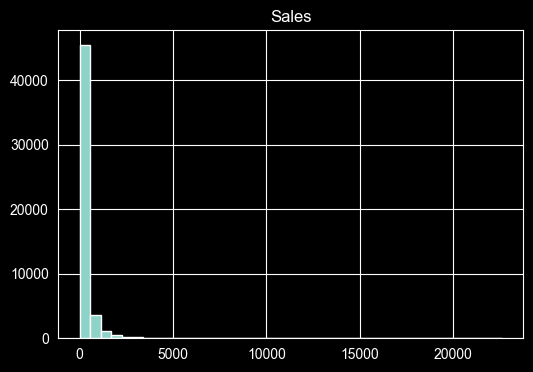

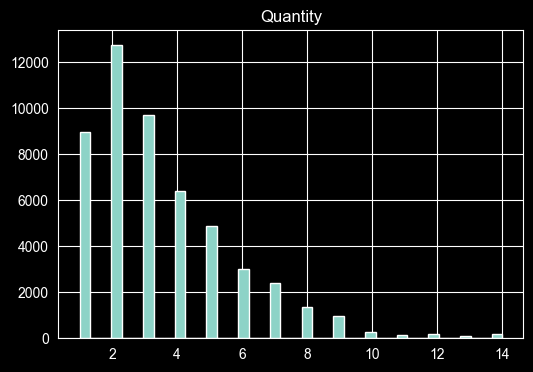

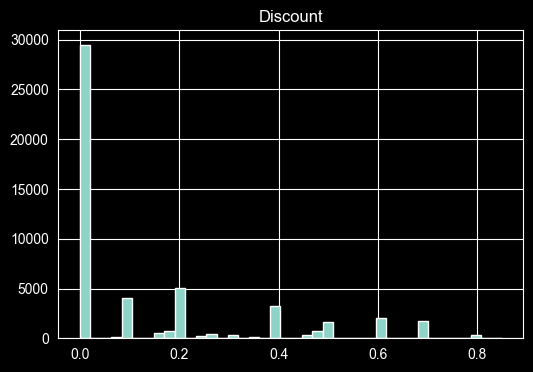

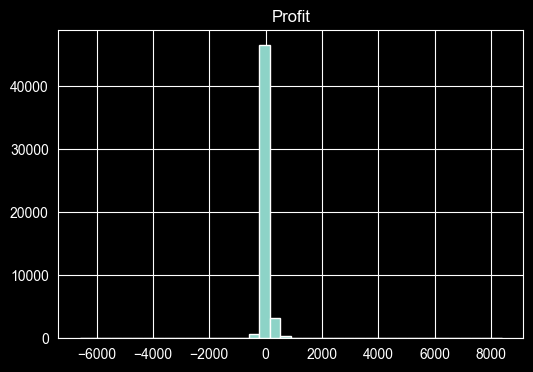

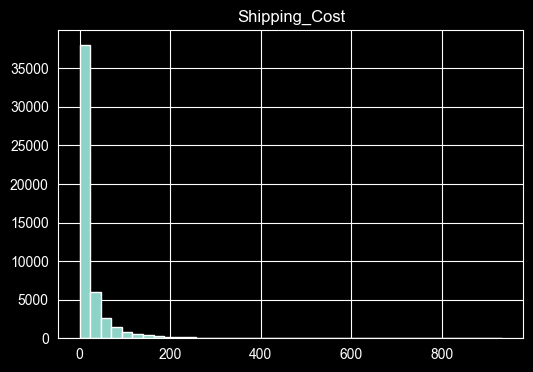

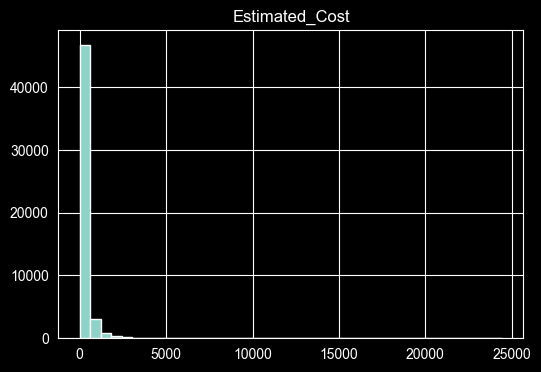

In [21]:
num_cols = ["Sales","Quantity","Discount","Profit",
            "Shipping_Cost","Estimated_Cost"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=40)
    plt.title(col)
    plt.show()

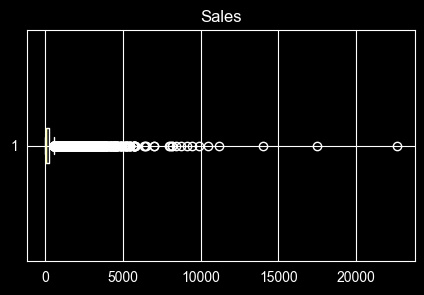

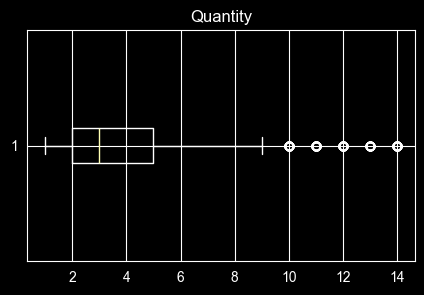

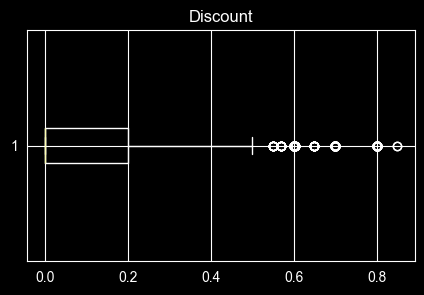

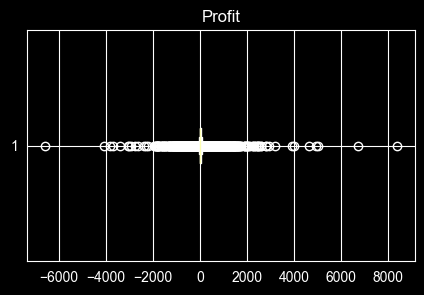

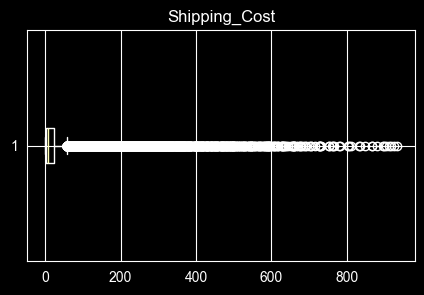

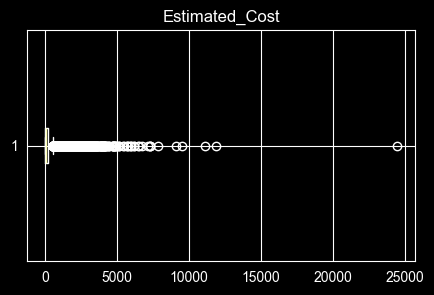

In [22]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

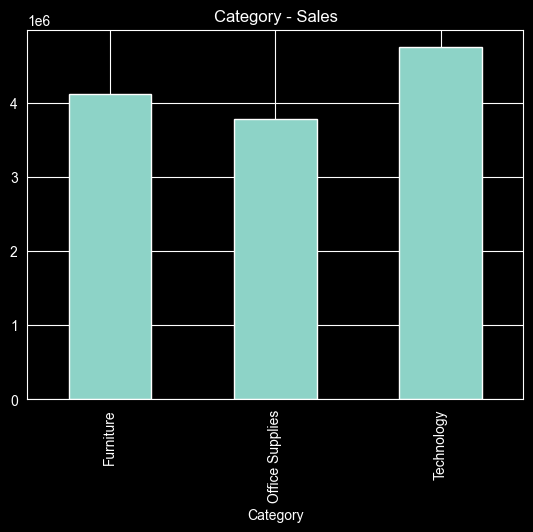

In [23]:
# Kategoriye göre satış
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")
plt.title("Category - Sales")
plt.show()

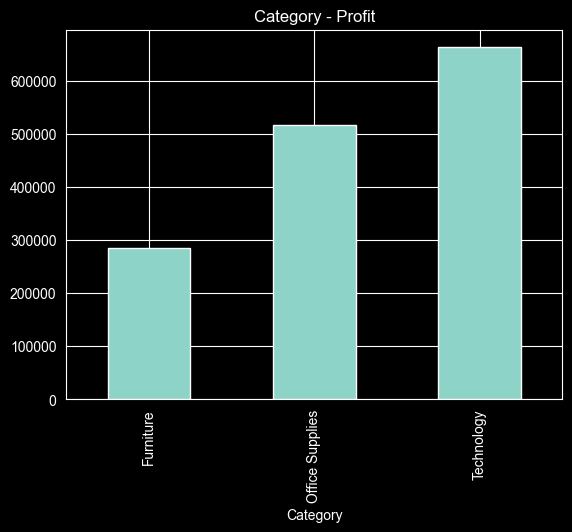

In [24]:
#kategoriye göre kar
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar")
plt.title("Category - Profit")
plt.show()

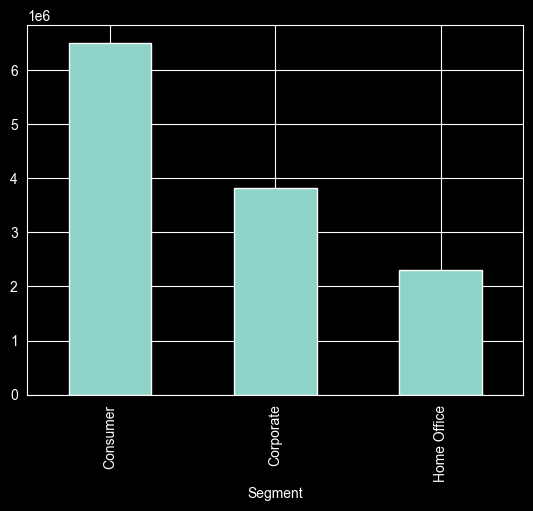

In [25]:
#segmente göre satış
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar")
plt.show()

<Figure size 800x500 with 0 Axes>

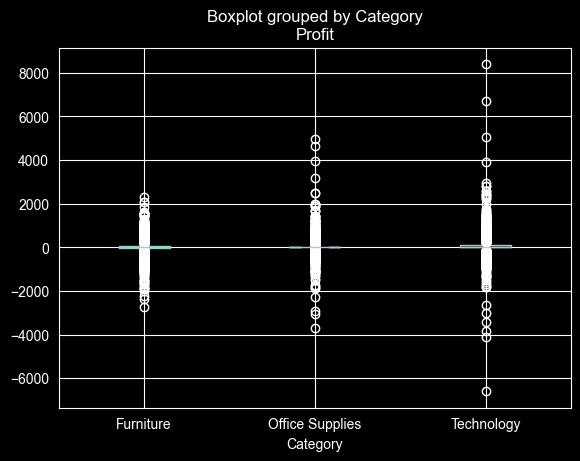

In [26]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="Profit",
    by="Category"
)

plt.show()

In [27]:
#Bu aykırı siparişler hangi kategorilerden geliyor?
df.nlargest(10, "Shipping_Cost")[
    ["Category",
     "Sub_Category",
     "Sales",
     "Shipping_Cost",
     "Profit",
     "Ship_Mode",
     "Country"]
]

,Category,Sub_Category,Sales,Shipping_Cost,Profit,Ship_Mode,Country
24777,Technology,Accessories,2309.650,933.57,762.1845,Same Day,United States
18159,Furniture,Chairs,3709.395,923.63,-288.7650,Second Class,Australia
17036,Technology,Phones,5175.171,915.49,919.9710,First Class,Australia
3918,Technology,Phones,2892.510,910.16,-96.5400,First Class,Germany
41359,Technology,Copiers,2832.960,903.04,311.5200,Same Day,Senegal
14149,Technology,Phones,2862.675,897.35,763.2750,Second Class,Australia
22858,Furniture,Chairs,1822.080,894.77,564.8400,First Class,New Zealand
23549,Furniture,Tables,5244.840,878.38,996.4800,Standard Class,New Zealand
33508,Office Supplies,Binders,5083.960,867.69,1906.4850,Standard Class,United States
34375,Furniture,Tables,4297.644,865.74,-1862.3124,Second Class,United States


Region
North Asia        40.646112
Central Asia      38.003003
Oceania           34.593780
Southeast Asia    29.937948
North             27.476299
Central           26.710494
East              25.542001
South             25.353509
West              23.887687
Caribbean         21.059260
Canada            19.285495
Africa            19.215058
EMEA              17.573221
Name: Shipping_Cost, dtype: float64


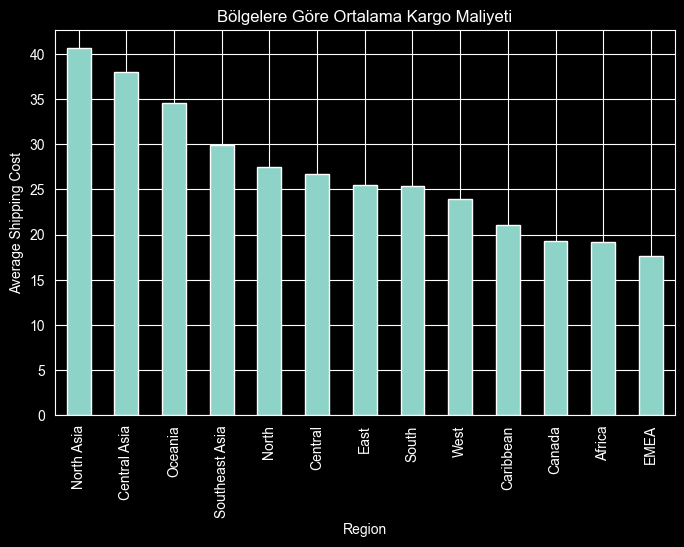

In [28]:
#Bu yüksek maliyetler hangi ülke veya bölgelerde yoğunlaşıyor?
region_ship = (
    df.groupby("Region")["Shipping_Cost"]
    .mean()
    .sort_values(ascending=False)
)

print(region_ship)

region_ship.plot(
    kind="bar",
    figsize=(8,5),
    title="Bölgelere Göre Ortalama Kargo Maliyeti"
)

plt.ylabel("Average Shipping Cost")
plt.show()

Country
Taiwan                      155.660714
Chad                        148.970000
Lesotho                     135.650000
Montenegro                   93.937500
Slovenia                     61.220000
Republic of the Congo        59.303333
Central African Republic     57.625714
Namibia                      50.370000
Bangladesh                   46.402883
Estonia                      46.070000
Name: Shipping_Cost, dtype: float64


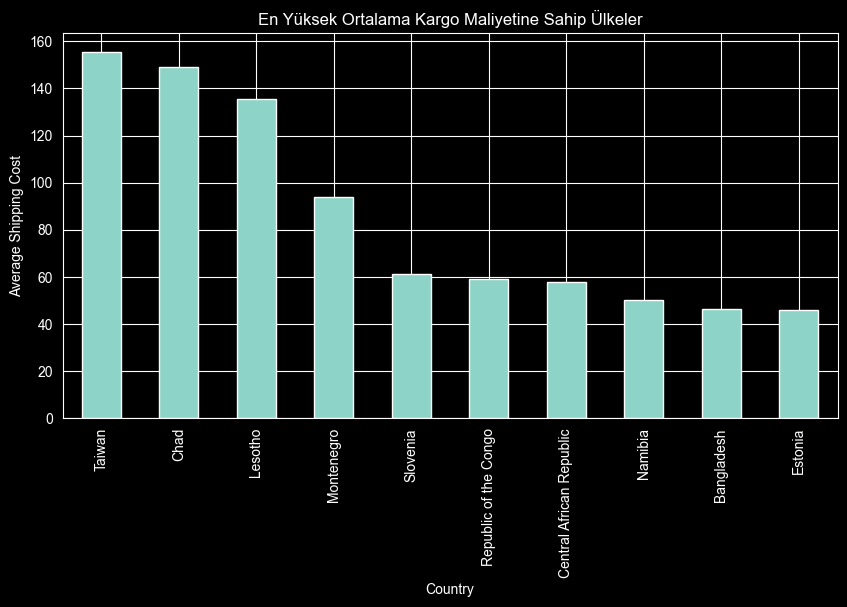

In [29]:
country_ship = (
    df.groupby("Country")["Shipping_Cost"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(country_ship)

country_ship.plot(
    kind="bar",
    figsize=(10,5),
    title="En Yüksek Ortalama Kargo Maliyetine Sahip Ülkeler"
)

plt.ylabel("Average Shipping Cost")
plt.show()

In [30]:
pd.pivot_table(
    df,
    values="Shipping_Cost",
    index="Region",
    columns="Ship_Mode",
    aggfunc="mean"
)

Ship_Mode,First Class,Same Day,Second Class,Standard Class
Region,,,,
Africa,29.154934,34.235136,23.210313,13.734566
Canada,27.634857,21.776897,29.541648,11.089536
Caribbean,32.356061,36.442000,25.672285,15.437365
Central,42.416026,43.882165,31.324596,20.100950
Central Asia,58.655754,68.366835,41.704068,30.773790
EMEA,25.792900,27.114433,23.042941,12.946222
East,37.041551,54.804065,27.151132,18.953096
North,41.736813,44.125813,30.849560,21.592789
North Asia,71.908234,54.513491,41.234106,30.637240


In [31]:
df.nlargest(
    20,
    "Shipping_Cost"
)[
    [
        "Country",
        "Region",
        "Ship_Mode",
        "Sales",
        "Shipping_Cost",
        "Profit"
    ]
] # En pahalı gönderiler hangi ülkelerde?

,Country,Region,Ship_Mode,Sales,Shipping_Cost,Profit
24777,United States,East,Same Day,2309.650,933.57,762.1845
18159,Australia,Oceania,Second Class,3709.395,923.63,-288.7650
17036,Australia,Oceania,First Class,5175.171,915.49,919.9710
3918,Germany,Central,First Class,2892.510,910.16,-96.5400
41359,Senegal,Africa,Same Day,2832.960,903.04,311.5200
14149,Australia,Oceania,Second Class,2862.675,897.35,763.2750
22858,New Zealand,Oceania,First Class,1822.080,894.77,564.8400
23549,New Zealand,Oceania,Standard Class,5244.840,878.38,996.4800
33508,United States,West,Standard Class,5083.960,867.69,1906.4850
34375,United States,South,Second Class,4297.644,865.74,-1862.3124
